In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

Matplotlib is building the font cache; this may take a moment.


In [21]:
refugees = pd.read_csv("../data/raw/temporary_protection.csv")
population = pd.read_csv("../data/raw/population.csv")
coordinates = pd.read_csv("../data/raw/coordinates.csv", sep = ';')

In [11]:
refugees.head()


,DATAFLOW,LAST UPDATE,freq,unit,citizen,sex,age,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:MIGR_ASYTPSM(1.0),01/07/26 23:00:00,Monthly,Person,Extra-EU27 (from 2020),Total,Total,Austria,2022-07,74770.0,NaN,NaN
1,ESTAT:MIGR_ASYTPSM(1.0),01/07/26 23:00:00,Monthly,Person,Extra-EU27 (from 2020),Total,Total,Austria,2022-08,77910.0,NaN,NaN
2,ESTAT:MIGR_ASYTPSM(1.0),01/07/26 23:00:00,Monthly,Person,Extra-EU27 (from 2020),Total,Total,Austria,2022-09,80755.0,NaN,NaN
3,ESTAT:MIGR_ASYTPSM(1.0),01/07/26 23:00:00,Monthly,Person,Extra-EU27 (from 2020),Total,Total,Austria,2022-10,83355.0,NaN,NaN
4,ESTAT:MIGR_ASYTPSM(1.0),01/07/26 23:00:00,Monthly,Person,Extra-EU27 (from 2020),Total,Total,Austria,2022-11,85445.0,NaN,NaN


In [12]:
refugees.info()
refugees.describe()
refugees.columns

<class 'pandas.DataFrame'>
RangeIndex: 1617 entries, 0 to 1616
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATAFLOW     1617 non-null   str    
 1   LAST UPDATE  1617 non-null   str    
 2   freq         1617 non-null   str    
 3   unit         1617 non-null   str    
 4   citizen      1617 non-null   str    
 5   sex          1617 non-null   str    
 6   age          1617 non-null   str    
 7   geo          1617 non-null   str    
 8   TIME_PERIOD  1617 non-null   str    
 9   OBS_VALUE    1612 non-null   float64
 10  OBS_FLAG     278 non-null    str    
 11  CONF_STATUS  0 non-null      float64
dtypes: float64(2), str(10)
memory usage: 310.5 KB


Index(['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'citizen', 'sex', 'age', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'], dtype='str')

In [9]:
refugees.isnull().sum()

DATAFLOW          0
LAST UPDATE       0
freq              0
unit              0
citizen           0
sex               0
age               0
geo               0
TIME_PERIOD       0
OBS_VALUE         5
OBS_FLAG       1339
CONF_STATUS    1617
dtype: int64

In [15]:
population.isnull().sum()

DATAFLOW          0
LAST UPDATE       0
freq              0
indic_de          0
geo               0
TIME_PERIOD       0
OBS_VALUE         0
OBS_FLAG       1030
CONF_STATUS    1140
dtype: int64

In [22]:
coordinates.head()

,latitude,longitude,Country
0,33.939110,67.709953,Afghanistan
1,41.153332,20.168331,Albania
2,28.033886,1.659626,Algeria
3,-14.270972,-170.132217,American Samoa
4,42.546245,1.601554,Andorra


In [23]:
coordinates.isnull().sum()

latitude     0
longitude    0
Country      0
dtype: int64

In [26]:
print(refugees.duplicated().sum())
print(population.duplicated().sum())
print(coordinates.duplicated().sum())

0
0
0


In [27]:
print(refugees.dtypes)
print(population.dtypes)
print(coordinates.dtypes)

DATAFLOW           str
LAST UPDATE        str
freq               str
unit               str
citizen            str
sex                str
age                str
geo                str
TIME_PERIOD        str
OBS_VALUE      float64
OBS_FLAG           str
CONF_STATUS    float64
dtype: object
DATAFLOW           str
LAST UPDATE        str
freq               str
indic_de           str
geo                str
TIME_PERIOD      int64
OBS_VALUE        int64
OBS_FLAG           str
CONF_STATUS    float64
dtype: object
latitude     float64
longitude    float64
Country          str
dtype: object


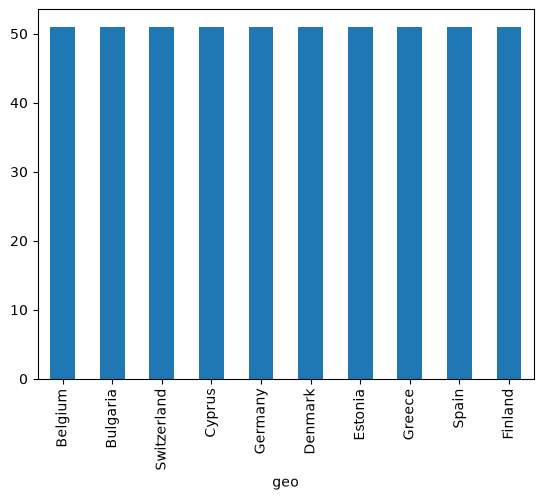

In [29]:
refugees["geo"].value_counts().head(10).plot(kind = "bar")
plt.show()

In [31]:
print(refugees.head())
print(refugees.info())

                  DATAFLOW        LAST UPDATE     freq    unit                 citizen    sex    age      geo TIME_PERIOD  OBS_VALUE OBS_FLAG  CONF_STATUS
0  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-07    74770.0      NaN          NaN
1  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-08    77910.0      NaN          NaN
2  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-09    80755.0      NaN          NaN
3  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-10    83355.0      NaN          NaN
4  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-11    85445.0      NaN          NaN
<class 'pandas.DataFrame'>
RangeIndex: 1617 entries, 0 to 1616
Data co

In [32]:
print(population.head())
print(population.info())

               DATAFLOW        LAST UPDATE    freq                         indic_de      geo  TIME_PERIOD  OBS_VALUE OBS_FLAG  CONF_STATUS
0  ESTAT:DEMO_GIND(1.0)  10/07/26 11:00:00  Annual  Population on 1 January - total  Andorra         2004      72320      NaN          NaN
1  ESTAT:DEMO_GIND(1.0)  10/07/26 11:00:00  Annual  Population on 1 January - total  Andorra         2005      76875      NaN          NaN
2  ESTAT:DEMO_GIND(1.0)  10/07/26 11:00:00  Annual  Population on 1 January - total  Andorra         2006      78549      NaN          NaN
3  ESTAT:DEMO_GIND(1.0)  10/07/26 11:00:00  Annual  Population on 1 January - total  Andorra         2007      81222      NaN          NaN
4  ESTAT:DEMO_GIND(1.0)  10/07/26 11:00:00  Annual  Population on 1 January - total  Andorra         2008      83137      NaN          NaN
<class 'pandas.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       -----------

In [33]:

print(coordinates.head())
print(coordinates.info())

    latitude   longitude         Country
0  33.939110   67.709953     Afghanistan
1  41.153332   20.168331         Albania
2  28.033886    1.659626         Algeria
3 -14.270972 -170.132217  American Samoa
4  42.546245    1.601554         Andorra
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   244 non-null    float64
 1   longitude  244 non-null    float64
 2   Country    244 non-null    str    
dtypes: float64(2), str(1)
memory usage: 8.2 KB
None


In [35]:
print(refugees.isnull().sum())
print(refugees.duplicated().sum())
print(refugees.columns)
print (refugees.head())

DATAFLOW          0
LAST UPDATE       0
freq              0
unit              0
citizen           0
sex               0
age               0
geo               0
TIME_PERIOD       0
OBS_VALUE         5
OBS_FLAG       1339
CONF_STATUS    1617
dtype: int64
0
Index(['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'citizen', 'sex', 'age', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'], dtype='str')
                  DATAFLOW        LAST UPDATE     freq    unit                 citizen    sex    age      geo TIME_PERIOD  OBS_VALUE OBS_FLAG  CONF_STATUS
0  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-07    74770.0      NaN          NaN
1  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-08    77910.0      NaN          NaN
2  ESTAT:MIGR_ASYTPSM(1.0)  01/07/26 23:00:00  Monthly  Person  Extra-EU27 (from 2020)  Total  Total  Austria     2022-09    8075

## Data cleaning

In [36]:
refugees = refugees[
    [
        "geo",
        "TIME_PERIOD",
        "OBS_VALUE",
        "citizen",
        "sex",
        "age"
    ]
]

refugees = refugees.dropna(subset=["OBS_VALUE"])

In [ ]:
print(refugees.isnull().sum())

geo            0
TIME_PERIOD    0
OBS_VALUE      0
citizen        0
sex            0
age            0
dtype: int64


In [39]:
refugees["TIME_PERIOD"] = pd.to_datetime(refugees["TIME_PERIOD"])

In [40]:
refugees.info()

<class 'pandas.DataFrame'>
Index: 1612 entries, 0 to 1616
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   geo          1612 non-null   str           
 1   TIME_PERIOD  1612 non-null   datetime64[us]
 2   OBS_VALUE    1612 non-null   float64       
 3   citizen      1612 non-null   str           
 4   sex          1612 non-null   str           
 5   age          1612 non-null   str           
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 152.3 KB


In [41]:
refugees["geo"].unique()

<ArrowStringArray>
[                                  'Austria',                                   'Belgium',                                  'Bulgaria',                               'Switzerland',
                                    'Cyprus',                                   'Czechia',                                   'Germany',                                   'Denmark',
                                   'Estonia',                                    'Greece',                                     'Spain', 'European Union - 27 countries (from 2020)',
                                   'Finland',                                    'France',                                   'Croatia',                                   'Hungary',
                                   'Ireland',                                   'Iceland',                                     'Italy',                             'Liechtenstein',
                                 'Lithuania',                               

In [43]:
poland = refugees[
    (refugees["geo"] == "Poland") & 
    (refugees["sex"] == "Total") & 
    (refugees["age"] == "Total")
]

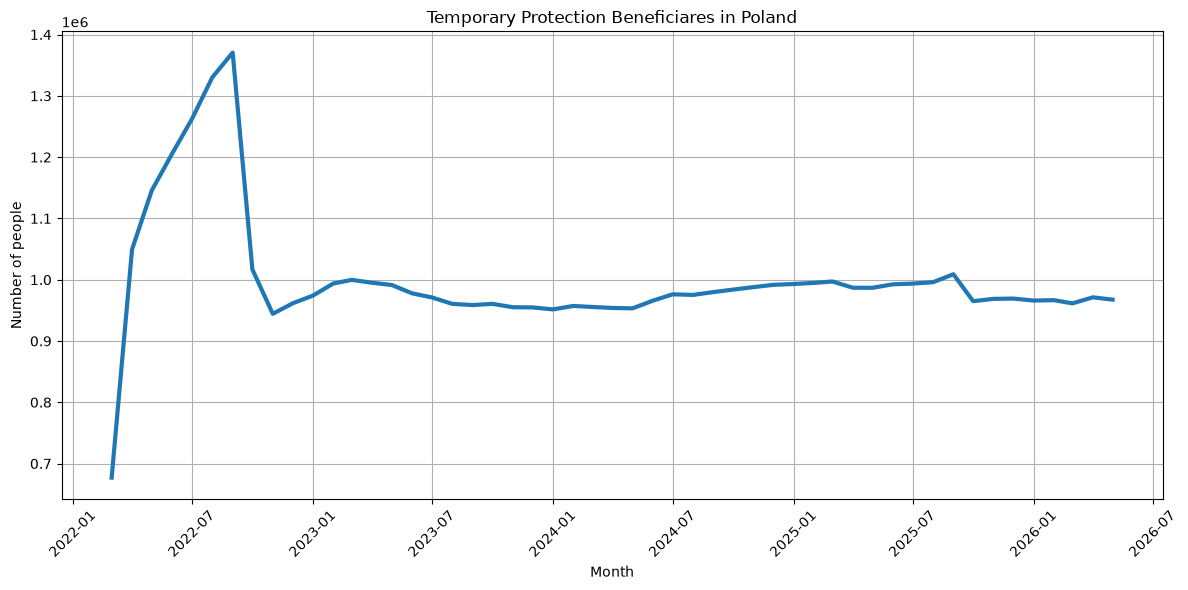

In [44]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))

plt.plot(
    poland["TIME_PERIOD"],
    poland["OBS_VALUE"],
    linewidth = 3
)

plt.title("Temporary Protection Beneficiares in Poland")
plt.xlabel("Month")
plt.ylabel("Number of people")
plt.grid(True)

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()